In [1]:
import requests
import sys
sys.path.append('sources')
headers = {
	"Content-Type": "application/json",
}
url = "http://127.0.0.1:8001/"

## Read a bundle from the CPI dataset

In [2]:
import random
from experiments.etl.read import read_cpi_bundles

x = 1
y = 1
bundles = read_cpi_bundles(x=x,y=y)
print("Size: ", len(bundles))

w = random.randint(0, len(bundles)-1)
print(f"x={x}, y={y}, w={w}")
bpmn = bundles[w].copy()
metedata = bpmn.pop('metadata')
bpmn

Size:  5400
x=1, y=1, w=4323


{'type': 'nature',
 'id': 0,
 'true': {'type': 'parallel',
  'id': 1,
  'first_split': {'type': 'task',
   'id': 2,
   'duration': 1,
   'impacts': {'impact_1': 0.08638829650035527}},
  'second_split': {'type': 'sequence',
   'id': 3,
   'head': {'type': 'task',
    'id': 4,
    'duration': 8,
    'impacts': {'impact_1': 0.05766302944225521}},
   'tail': {'type': 'task',
    'id': 5,
    'duration': 6,
    'impacts': {'impact_1': 0.04450137568111241}}}},
 'false': {'type': 'task',
  'id': 6,
  'duration': 2,
  'impacts': {'impact_1': 0.09681053443757306}},
 'probability': 0.9062220404050056}

### Check BPMN

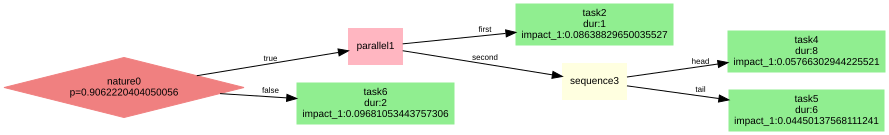

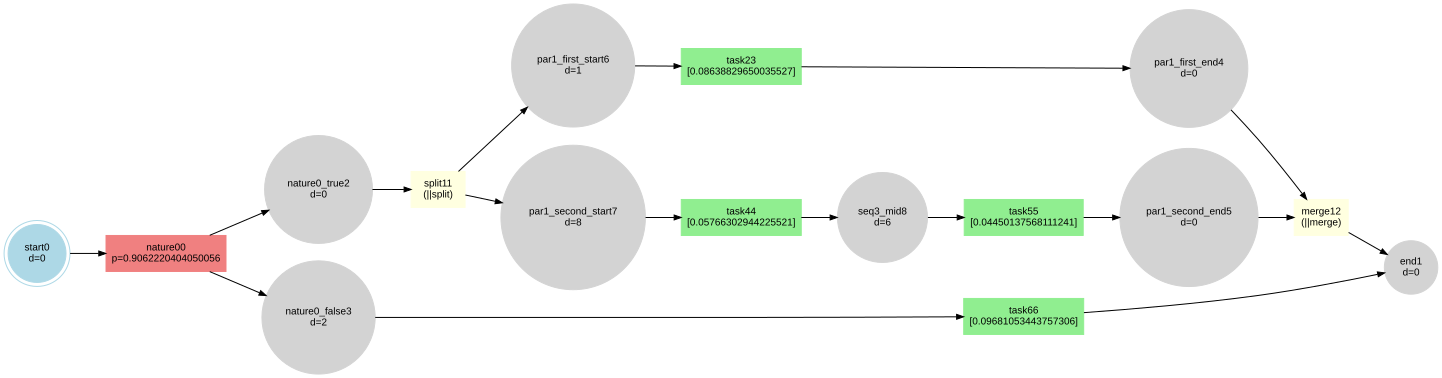

In [3]:
import graphviz
from IPython.display import display, SVG

try:
	resp = requests.get(f'{url}create_spin', json={'cpi_dict': bpmn},  headers=headers)
	resp.raise_for_status()
	response = resp.json()
	display(SVG(graphviz.Source(response['cpi_dot']).pipe(format="svg")))
	display(SVG(graphviz.Source(response['spin_dot']).pipe(format="svg")))
	prism_model = response['prism_model']

except requests.exceptions.HTTPError as e:
	print(f"HTTP Error ({resp.status_code}):", resp.json())

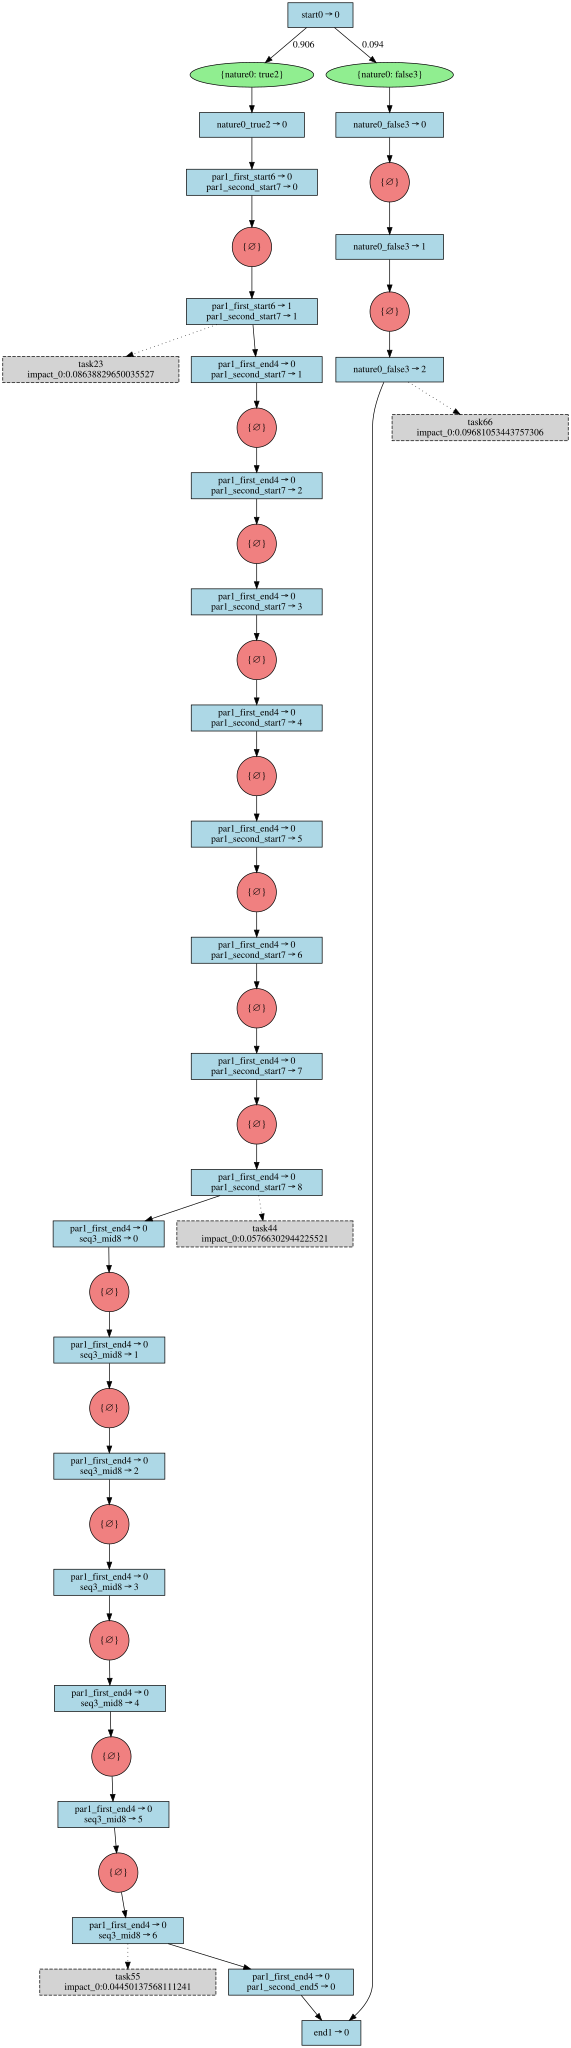

In [4]:
try:
	resp = requests.get(f'{url}run_prism_analysis', json={'cpi_dict': bpmn},  headers=headers)
	resp.raise_for_status()
	response = resp.json()
	display(SVG(graphviz.Source(response['mdp_dot']).pipe(format="svg")))

except requests.exceptions.HTTPError as e:
	print(f"HTTP Error ({resp.status_code}):", resp.json())